In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from sklearn.metrics import classification_report
import statsmodels.api as sm
from sklearn.linear_model import LogisticRegression

# VIF Check
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
# Load Data
df = pd.read_csv("Leads.csv")
df.head()
df.shape
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

In [3]:
# Check null values
df.isnull().sum().sort_values(ascending=False)

Lead Quality                                     4767
Asymmetrique Activity Index                      4218
Asymmetrique Profile Score                       4218
Asymmetrique Activity Score                      4218
Asymmetrique Profile Index                       4218
Tags                                             3353
Lead Profile                                     2709
What matters most to you in choosing a course    2709
What is your current occupation                  2690
Country                                          2461
How did you hear about X Education               2207
Specialization                                   1438
City                                             1420
Page Views Per Visit                              137
TotalVisits                                       137
Last Activity                                     103
Lead Source                                        36
Receive More Updates About Our Courses              0
I agree to pay the amount th

In [4]:
# Percentage missing values
round((df.isnull().sum()/len(df))*100,2).sort_values(ascending=False)

Lead Quality                                     51.59
Asymmetrique Activity Index                      45.65
Asymmetrique Profile Score                       45.65
Asymmetrique Activity Score                      45.65
Asymmetrique Profile Index                       45.65
Tags                                             36.29
Lead Profile                                     29.32
What matters most to you in choosing a course    29.32
What is your current occupation                  29.11
Country                                          26.63
How did you hear about X Education               23.89
Specialization                                   15.56
City                                             15.37
Page Views Per Visit                              1.48
TotalVisits                                       1.48
Last Activity                                     1.11
Lead Source                                       0.39
Receive More Updates About Our Courses            0.00
I agree to

In [5]:
# Data Cleaning
df = df.replace('Select', np.nan)

In [6]:
# dropping columns
df.drop(['Prospect ID','Lead Number'], axis=1, inplace=True)

In [7]:
# dropping columns with more than 40% missing values
missing = round((df.isnull().sum()/len(df))*100,2)

cols_to_drop = missing[missing > 40].index

df.drop(cols_to_drop, axis=1, inplace=True)

In [8]:
round((df.isnull().sum()/len(df))*100,2).sort_values(ascending=False)

City                                             39.71
Specialization                                   36.58
Tags                                             36.29
What matters most to you in choosing a course    29.32
What is your current occupation                  29.11
Country                                          26.63
TotalVisits                                       1.48
Page Views Per Visit                              1.48
Last Activity                                     1.11
Lead Source                                       0.39
Receive More Updates About Our Courses            0.00
Update me on Supply Chain Content                 0.00
Lead Origin                                       0.00
Digital Advertisement                             0.00
Get updates on DM Content                         0.00
I agree to pay the amount through cheque          0.00
A free copy of Mastering The Interview            0.00
Through Recommendations                           0.00
Magazine  

# MISSING VALUE TREATMENT

In [9]:
# Categorical Columns → Mode
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [10]:
# Numeric Columns → Median
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [11]:
df.isnull().sum().sum()

np.int64(0)

# EDA

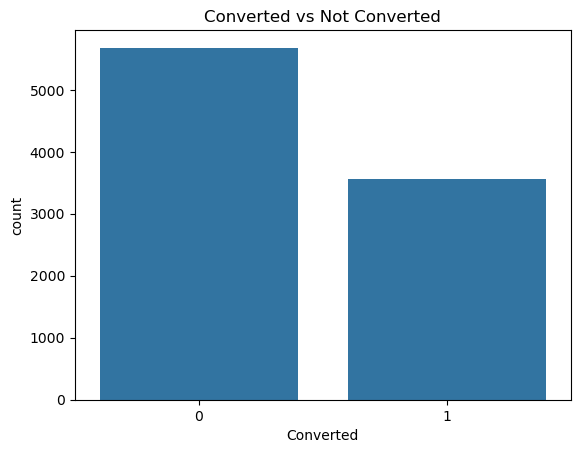

In [12]:
# Target Variable Distribution
sns.countplot(x='Converted', data=df)
plt.title("Converted vs Not Converted")
plt.show()

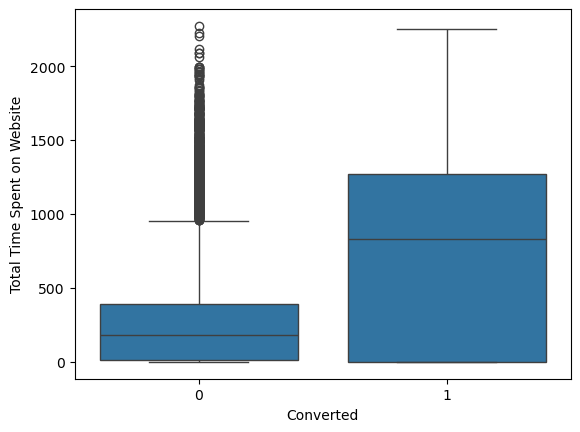

In [13]:
# Time Spent vs Conversion
sns.boxplot(x='Converted', y='Total Time Spent on Website', data=df)
plt.show()

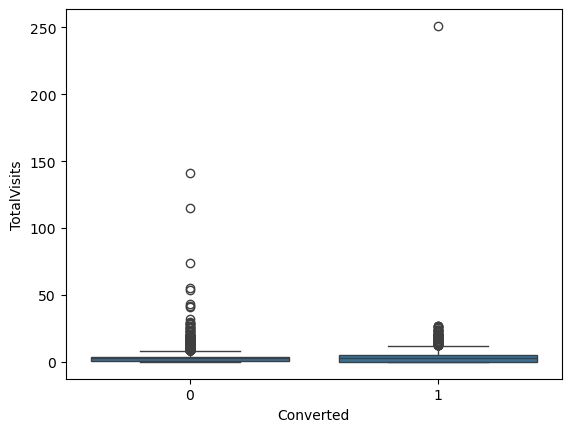

In [14]:
# Total Visits vs Conversion
sns.boxplot(x='Converted', y='TotalVisits', data=df)
plt.show()

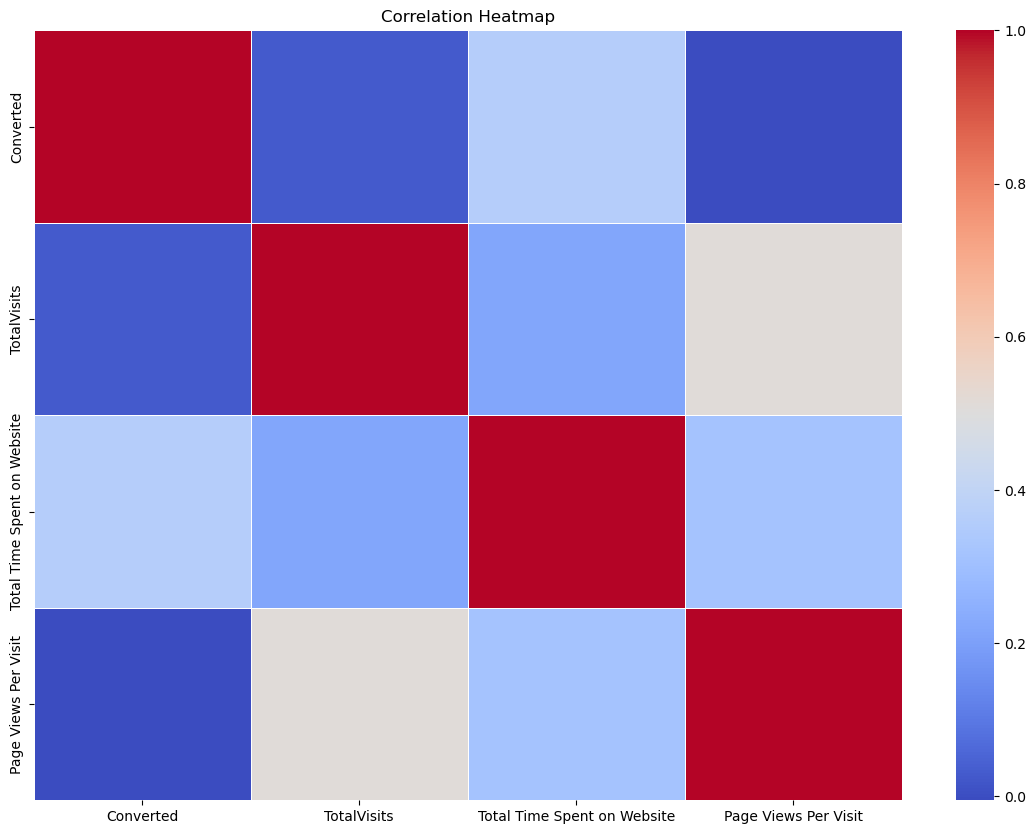

In [15]:
# correlation heatmap
numeric_df = df.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(14,10))
corr = numeric_df.corr()

sns.heatmap(
    corr,
    annot=False,
    cmap='coolwarm',
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

In [16]:
# Convert categorical columns to dummy variables
df = pd.get_dummies(df, drop_first=True)

In [17]:
df.shape

(9240, 159)

In [18]:
df.head()

,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,Lead Origin_Landing Page Submission,Lead Origin_Lead Add Form,Lead Origin_Lead Import,Lead Origin_Quick Add Form,Lead Source_Direct Traffic,Lead Source_Facebook,...,Last Notable Activity_Form Submitted on Website,Last Notable Activity_Had a Phone Conversation,Last Notable Activity_Modified,Last Notable Activity_Olark Chat Conversation,Last Notable Activity_Page Visited on Website,Last Notable Activity_Resubscribed to emails,Last Notable Activity_SMS Sent,Last Notable Activity_Unreachable,Last Notable Activity_Unsubscribed,Last Notable Activity_View in browser link Clicked
0,0,0.0,0,0.0,False,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False
1,0,5.0,674,2.5,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,1,2.0,1532,2.0,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,0,1.0,305,1.0,True,False,False,False,True,False,...,False,False,True,False,False,False,False,False,False,False
4,1,2.0,1428,1.0,True,False,False,False,False,False,...,False,False,True,False,False,False,False,False,False,False


# Train_test split

In [19]:
# Define X and y
X = df.drop('Converted', axis=1)
y = df['Converted']

In [20]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=100
)

In [21]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(6468, 158)
(2772, 158)
(6468,)
(2772,)


In [22]:
# Feature Scaling
scaler = StandardScaler()

num_vars = ['TotalVisits','Total Time Spent on Website','Page Views Per Visit']

X_train[num_vars] = scaler.fit_transform(X_train[num_vars])

X_test[num_vars] = scaler.transform(X_test[num_vars])

# first logistic regression model

In [23]:
from sklearn.linear_model import LogisticRegression

# Build model
lr = LogisticRegression(max_iter=2000)

lr.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,2000
,multi_class,'deprecated'


In [24]:
y_train_pred = lr.predict(X_train)

accuracy_score(y_train, y_train_pred)

0.9004329004329005

In [25]:
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': lr.coef_[0]
})

coef_df.sort_values(by='Coefficient', ascending=False).head(20)

,Feature,Coefficient
121,Tags_Lost to EINS,6.033465
113,Tags_Closed by Horizzon,5.860413
130,Tags_Will revert after reading the email,2.566583
4,Lead Origin_Lead Add Form,2.334567
112,Tags_Busy,1.824475
120,Tags_Lateral student,1.609692
103,What is your current occupation_Working Profes...,1.366631
20,Lead Source_Welingak Website,1.334614
154,Last Notable Activity_SMS Sent,1.271677
131,Tags_in touch with EINS,1.195239


In [26]:
top_features = coef_df.sort_values(by='Coefficient', ascending=False)['Feature'].head(20).tolist()

In [27]:
X_train_top = X_train[top_features]
X_test_top = X_test[top_features]

In [28]:
# Convert all columns to numeric float

X_train_top = X_train_top.astype(float)
X_test_top = X_test_top.astype(float)

# Also ensure target is integer
y_train = y_train.astype(int)
y_test = y_test.astype(int)

In [29]:
X_train_sm = sm.add_constant(X_train_top)

logm2 = sm.GLM(
    y_train,
    X_train_sm,
    family=sm.families.Binomial()
).fit()

print(logm2.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              Converted   No. Observations:                 6468
Model:                            GLM   Df Residuals:                     6447
Model Family:                Binomial   Df Model:                           20
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1835.4
Date:                Wed, 22 Apr 2026   Deviance:                       3670.7
Time:                        19:09:44   Pearson chi2:                 1.00e+04
No. Iterations:                    22   Pseudo R-squ. (CS):             0.5332
Covariance Type:            nonrobust                                         
                                                             coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------

# Remove High P-value Variables

In [30]:
remove_cols = [
    'Tags_Lateral student',
    'Last Notable Activity_Email Bounced',
    'Tags_Interested in Next batch',
    'Tags_Shall take in the next coming month',
    'What is your current occupation_Housewife',
    'Country_United States',
    'Country_Hong Kong'
]

X_train_top.drop(remove_cols, axis=1, inplace=True)
X_test_top.drop(remove_cols, axis=1, inplace=True)

In [31]:
X_train_sm = sm.add_constant(X_train_top)

logm3 = sm.GLM(
    y_train,
    X_train_sm,
    family=sm.families.Binomial()
).fit()

print(logm3.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:              Converted   No. Observations:                 6468
Model:                            GLM   Df Residuals:                     6454
Model Family:                Binomial   Df Model:                           13
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -1864.7
Date:                Wed, 22 Apr 2026   Deviance:                       3729.4
Time:                        19:09:50   Pearson chi2:                 1.04e+04
No. Iterations:                     9   Pseudo R-squ. (CS):             0.5289
Covariance Type:            nonrobust                                         
                                                             coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------

In [32]:
# Check multicollinearity

vif = pd.DataFrame()
vif["Feature"] = X_train_top.columns
vif["VIF"] = [variance_inflation_factor(X_train_top.values, i) for i in range(X_train_top.shape[1])]
vif["VIF"] = round(vif["VIF"], 2)

vif.sort_values(by="VIF", ascending=False)

,Feature,VIF
3,Lead Origin_Lead Add Form,1.63
2,Tags_Will revert after reading the email,1.34
7,Last Notable Activity_SMS Sent,1.34
6,Lead Source_Welingak Website,1.24
1,Tags_Closed by Horizzon,1.23
5,What is your current occupation_Working Profes...,1.21
9,Total Time Spent on Website,1.08
4,Tags_Busy,1.03
10,Last Notable Activity_Had a Phone Conversation,1.03
12,Tags_Want to take admission but has financial ...,1.02


In [33]:
# Predict Probabilities on Train Data
# Add constant
X_train_sm = sm.add_constant(X_train_top)

# Predict probabilities
y_train_pred = logm3.predict(X_train_sm)

In [34]:
# Create Prediction DataFrame
y_train_final = pd.DataFrame()

y_train_final['Converted'] = y_train.values
y_train_final['Conversion_Prob'] = y_train_pred

In [35]:
y_train_final.head()

,Converted,Conversion_Prob
0,0,NaN
1,0,0.007597
2,0,0.751478
3,0,NaN
4,0,0.712945


In [36]:
y_train_final['Predicted'] = y_train_final['Conversion_Prob'].apply(
    lambda x: 1 if x > 0.40 else 0
)

In [37]:
# Confusion matrix
confusion_matrix(y_train_final['Converted'], y_train_final['Predicted'])

array([[2859, 1143],
       [1798,  668]])

In [38]:
# Accuracy
accuracy_score(y_train_final['Converted'], y_train_final['Predicted'])

0.545299938157081

In [39]:
# classification report
print(classification_report(
    y_train_final['Converted'],
    y_train_final['Predicted']
))

              precision    recall  f1-score   support

           0       0.61      0.71      0.66      4002
           1       0.37      0.27      0.31      2466

    accuracy                           0.55      6468
   macro avg       0.49      0.49      0.49      6468
weighted avg       0.52      0.55      0.53      6468



In [40]:
X_test_sm = sm.add_constant(X_test_top)

y_test_pred = logm3.predict(X_test_sm)

In [45]:
# Reset index first

y_test_final = pd.DataFrame()

y_test_final['Converted'] = y_test.reset_index(drop=True)

y_test_final['Conversion_Prob'] = pd.Series(y_test_pred).reset_index(drop=True)

# Lead score
y_test_final['Lead_Score'] = y_test_final['Conversion_Prob'] * 100

# Final prediction
y_test_final['Predicted'] = y_test_final['Conversion_Prob'].apply(
    lambda x: 1 if x > 0.40 else 0
)

y_test_final.head()

,Converted,Conversion_Prob,Lead_Score,Predicted
0,1,0.937528,93.752775,1
1,1,0.978738,97.873849,1
2,1,0.772286,77.228578,1
3,0,0.002134,0.213378,0
4,1,0.775834,77.583421,1


# Test Evaluation

In [46]:
confusion_matrix(y_test_final['Converted'], y_test_final['Predicted'])

array([[1521,  156],
       [ 139,  956]])

In [47]:
accuracy_score(y_test_final['Converted'], y_test_final['Predicted'])

0.8935786435786436

In [48]:
roc_auc_score(y_test_final['Converted'], y_test_final['Conversion_Prob'])

0.9414776331947405

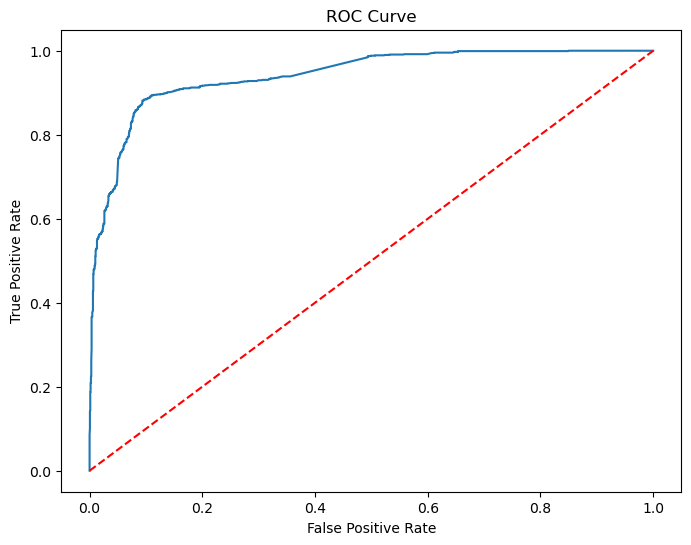

In [49]:
# ROC curve
fpr, tpr, thresholds = roc_curve(
    y_test_final['Converted'],
    y_test_final['Conversion_Prob']
)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1], 'r--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.show()

In [50]:
# Final Variable Importance
coef_df = pd.DataFrame({
    'Feature': X_train_top.columns,
    'Coefficient': logm3.params[1:]
})

coef_df.sort_values(by='Coefficient', ascending=False)

,Feature,Coefficient
Tags_Closed by Horizzon,Tags_Closed by Horizzon,9.483965
Tags_Lost to EINS,Tags_Lost to EINS,8.982566
Tags_Will revert after reading the email,Tags_Will revert after reading the email,4.355494
Tags_in touch with EINS,Tags_in touch with EINS,4.305734
Tags_Busy,Tags_Busy,3.739453
Last Notable Activity_Had a Phone Conversation,Last Notable Activity_Had a Phone Conversation,3.428042
Lead Origin_Lead Add Form,Lead Origin_Lead Add Form,3.033783
What is your current occupation_Working Professional,What is your current occupation_Working Profes...,2.901858
Tags_Want to take admission but has financial problems,Tags_Want to take admission but has financial ...,2.759575
Last Notable Activity_SMS Sent,Last Notable Activity_SMS Sent,2.587813


The logistic regression model successfully predicts lead conversion probability.

Leads with higher scores should be prioritized by sales team.

Threshold can be changed based on business requirement:
- Lower threshold = more aggressive targeting
- Higher threshold = fewer but stronger leads